In [15]:
# Imports EDIT ALL this later
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from fpppy.utils import plot_series
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf
from utilsforecast.plotting import plot_series as plot_series_utils

In [4]:
# plot config
plt.style.use("ggplot")
import matplotlib as mpl
from cycler import cycler

mpl.rcParams["axes.prop_cycle"] = cycler(color=["#000000", "#000000"])

plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
    }
)

pd.set_option("max_colwidth", 100)

In [5]:
# Load Full Paths
path = r"S:\WP Personnel\A - Workforce\Data science student\Desys Corner"
# Load CSVs
leavers = pd.read_csv(
    f"{path}\\NHS_Leavers_Detail.csv", parse_dates=["Termination Date"], dayfirst=True
)
hires = pd.read_csv(
    f"{path}\\Hires_Detail_New.csv", parse_dates=["Latest Start Date"], dayfirst=True
)
sickness = pd.read_csv(
    f"{path}\\Sickness_Percentage_New.csv", parse_dates=["Month"], dayfirst=True
)

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_27720\3391469944.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sickness =  pd.read_csv(f"{path}\\Sickness_Percentage_New.csv", parse_dates=["Month"], dayfirst=True)


In [6]:
sickness["Abs (FTE)"] = pd.to_numeric(sickness["Abs (FTE)"], errors="coerce")
sickness["Avail (FTE)"] = pd.to_numeric(sickness["Avail (FTE)"], errors="coerce")

In [7]:
# Prepare Leavers
leavers.dropna(subset=["Termination Date"], inplace=True)
leavers["ds"] = leavers["Termination Date"].dt.to_period("M").dt.to_timestamp()
leavers["Org"] = leavers["Organisation"].str.replace(r"\s+", "", regex=True)
leavers["Service"] = leavers["Service group"].str.replace(r"\s+", "", regex=True)
leavers["Staff"] = leavers["Staff Group"].str.replace(r"\s+", "", regex=True)
leavers["Dep"] = leavers["Department"].str.replace(r"\s+", "", regex=True)
leavers["unique_id"] = (
    leavers["Org"]
    + "_"
    + leavers["Service"]
    + "_"
    + leavers["Staff"]
    + "_"
    + leavers["Dep"]
)

leavers_monthly = (
    leavers.groupby(["unique_id", "ds"]).size().reset_index(name="leavers_count")
)

# Prepare Hires
hires.dropna(subset=["Latest Start Date"], inplace=True)
hires["ds"] = hires["Latest Start Date"].dt.to_period("M").dt.to_timestamp()
hires["Org"] = hires["Organisation"].str.replace(r"\s+", "", regex=True)
hires["Service"] = hires["Service group"].str.replace(r"\s+", "", regex=True)
hires["Staff"] = hires["Staff Group"].str.replace(r"\s+", "", regex=True)
hires["Dep"] = hires["Department"].str.replace(r"\s+", "", regex=True)
hires["unique_id"] = (
    hires["Org"] + "_" + hires["Service"] + "_" + hires["Staff"] + "_" + hires["Dep"]
)

hires_monthly = (
    hires.groupby(["unique_id", "ds"]).size().reset_index(name="hires_count")
)

# Prepare Sickness
sickness.dropna(subset=["Month"], inplace=True)
sickness["Month"] = pd.to_datetime(sickness["Month"], errors="coerce")
sickness["ds"] = sickness["Month"].dt.to_period("M").dt.to_timestamp()
sickness["Org"] = sickness["Organisation"].str.replace(r"\s+", "", regex=True)
sickness["Service"] = sickness["Service Group"].str.replace(r"\s+", "", regex=True)
sickness["Staff"] = sickness["Staff Group"].str.replace(r"\s+", "", regex=True)
sickness["Dep"] = sickness["Department"].str.replace(r"\s+", "", regex=True)
sickness["unique_id"] = (
    sickness["Org"]
    + "_"
    + sickness["Service"]
    + "_"
    + sickness["Staff"]
    + "_"
    + sickness["Dep"]
)

sickness_monthly = (
    sickness.groupby(["unique_id", "ds"])
    .agg({"Abs (FTE)": "sum", "Avail (FTE)": "sum"})
    .reset_index()
)

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_27720\950618758.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sickness["Month"] = pd.to_datetime(sickness["Month"], errors="coerce")


In [8]:
sickness_monthly["sickness_pct"] = np.where(
    (sickness_monthly["Avail (FTE)"] > 0) & (sickness_monthly["Abs (FTE)"].notna()),
    (sickness_monthly["Abs (FTE)"] / sickness_monthly["Avail (FTE)"]) * 100,
    np.nan,
)

sickness_monthly["sickness_pct"] = sickness_monthly["sickness_pct"].round(2)

In [9]:
# Merge all monthy data
df_combined = leavers_monthly.merge(
    hires_monthly, on=["unique_id", "ds"], how="outer"
).merge(
    sickness_monthly[["unique_id", "ds", "sickness_pct"]],
    on=["unique_id", "ds"],
    how="outer",
)

#  Fill NaNs with 0 where appropriate
df_combined["leavers_count"] = df_combined["leavers_count"].fillna(0)
df_combined["hires_count"] = df_combined["hires_count"].fillna(0)
df_combined["sickness_pct"] = df_combined["sickness_pct"].fillna(method="ffill")

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_27720\2510344045.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined["sickness_pct"] = df_combined["sickness_pct"].fillna(method="ffill")


In [10]:
(sickness[["Abs (FTE)", "Avail (FTE)"]].describe())

,Abs (FTE),Avail (FTE)
count,38929.000000,37657.000000
mean,11.288348,174.064454
std,26.715840,204.049380
min,0.000000,0.000000
25%,0.000000,31.000000
50%,0.530000,87.200000
75%,12.000000,240.150000
max,876.930000,999.030000


In [11]:
(df_combined.head())

,unique_id,ds,leavers_count,hires_count,sickness_pct
0,A&EAdminTeam76200_MedicalServices_AdministrativeandClerical_EmergencyCareDEPT,2021-07-01,0.0,2.0,NaN
1,A&EAdminTeam76200_MedicalServices_AdministrativeandClerical_EmergencyCareDEPT,2021-08-01,0.0,1.0,NaN
2,A&EAdminTeam76200_MedicalServices_AdministrativeandClerical_EmergencyCareDEPT,2021-09-01,0.0,3.0,NaN
3,A&EAdminTeam76200_MedicalServices_AdministrativeandClerical_EmergencyCareDEPT,2022-05-01,0.0,1.0,NaN
4,A&EAdminTeam76200_MedicalServices_AdministrativeandClerical_EmergencyCareDEPT,2022-11-01,0.0,2.0,NaN


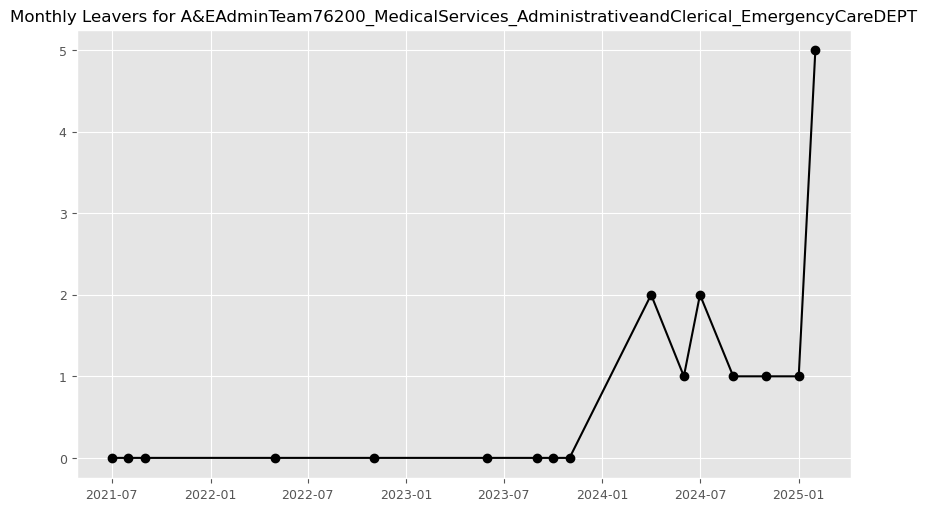

In [12]:
# Plot sample time series
example_uid = df_combined["unique_id"].dropna().unique()[0]
example_data = (
    df_combined[df_combined["unique_id"] == example_uid].sort_values("ds").copy()
)
plot_df = example_data.rename(columns={"leavers_count": "y"})

fig = plot_series_utils(df=plot_df, ids=[example_uid], plot_random=False, max_ids=1)
plt.plot(plot_df["ds"], plot_df["y"], marker="o")
plt.title(f"Monthly Leavers for {example_uid}")
plt.grid(True)
plt.show()

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_27720\1666149014.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


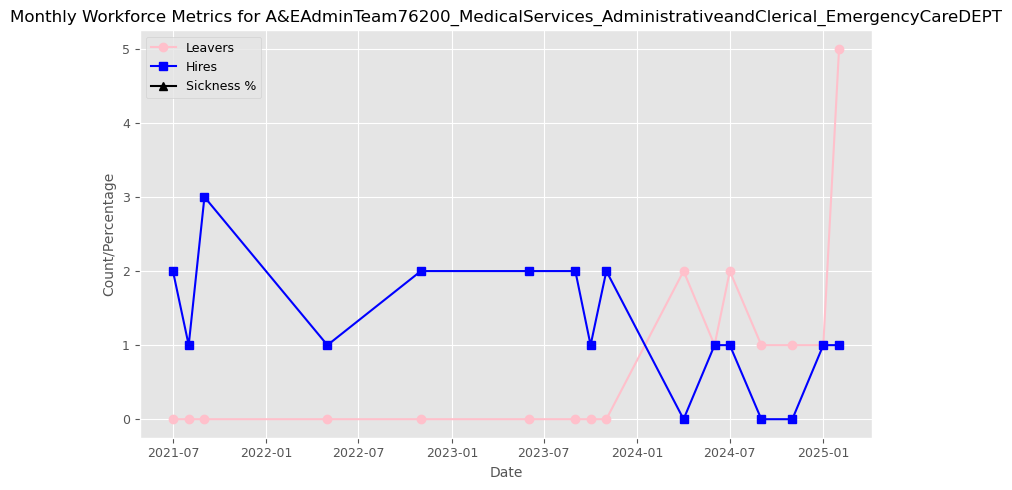

In [14]:
plt.plot(
    example_data["ds"],
    example_data["leavers_count"],
    label="Leavers",
    color="pink",
    marker="o",
)
plt.plot(
    example_data["ds"],
    example_data["hires_count"],
    label="Hires",
    color="blue",
    marker="s",
)
plt.plot(
    example_data["ds"], example_data["sickness_pct"], label="Sickness %", marker="^"
)

plt.title(f"Monthly Workforce Metrics for {example_uid}")
plt.xlabel("Date")
plt.ylabel("Count/Percentage")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_27720\933034726.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


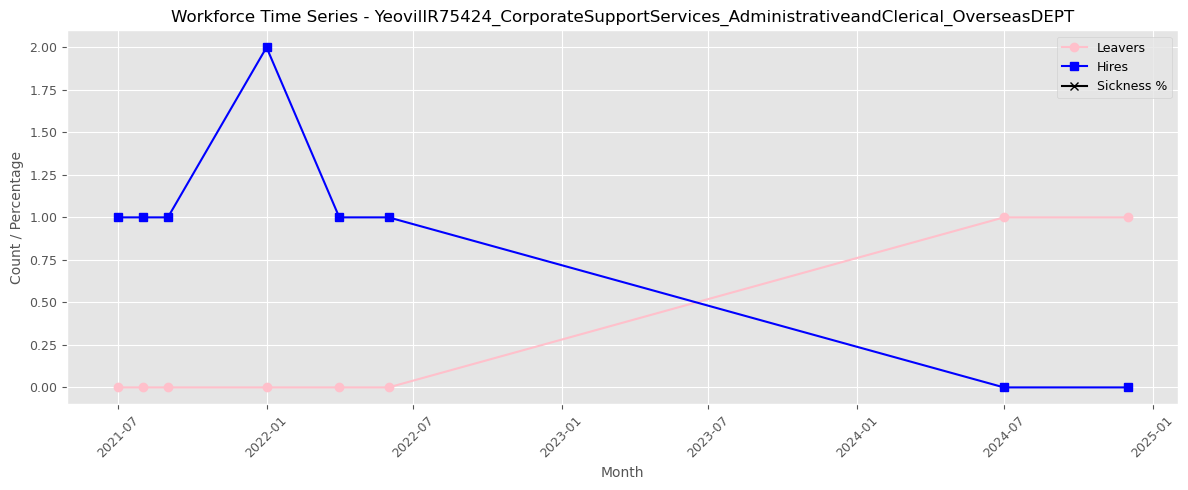

 All plots saved to: time_series_group_plots
Data exported to: merged_workforce_data.csv


In [21]:
# Set output folder
output_dir = "time_series_group_plots"
os.makedirs(output_dir, exist_ok=True)

# Loop through each unique Id
uids = df_combined["unique_id"].dropna().unique()

for uid in uids:
    group_data = df_combined[df_combined["unique_id"] == uid].sort_values("ds")
    # Skip groups with little data
    if len(group_data) < 6:
        continue

plt.figure(figsize=(12, 5))

plt.plot(
    group_data["ds"],
    group_data["leavers_count"],
    label="Leavers",
    color="pink",
    marker="o",
)
plt.plot(
    group_data["ds"], group_data["hires_count"], label="Hires", color="blue", marker="s"
)
plt.plot(group_data["ds"], group_data["sickness_pct"], label="Sickness %", marker="x")

plt.title(f"Workforce Time Series - {uid}")
plt.xlabel("Month")
plt.ylabel("Count / Percentage")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save to file
safe_uid = uid.replace("/", "_").replace("\\", "_")
file_path = os.path.join(output_dir, f"{safe_uid}.png")
plt.savefig(file_path)
plt.close()

print(f" All plots saved to: {output_dir}")

df_combined.to_csv("merged_workforce_data.csv", index=False)
print("Data exported to: merged_workforce_data.csv")